# Phase II Follow-up AI literacy questionnaire

In [26]:
import importlib
import pandas as pd
import numpy as np
import re
from pathlib import Path

import functions
import functions_Network
importlib.reload(functions)
importlib.reload(functions_Network)
from functions import *
from functions_Network import *
from phase_2_functions import *

In [27]:
df_analysis_phase_I = pd.read_csv("datasets/df_analysis_phase_I.csv")
followup_1111 = pd.read_csv("datasets/AI_Lit_follow_1111.csv")

df_pre, meta = prepare_dataset("datasets/AI_Lit_Que_1111.csv", "datasets/AI_Lit_Que_1204.csv")

# EFA for AI literacy
ai_efa_items = [
    "ai_concept_data_bias_scored_num",
    "ai_concept_blackbox_scored_num",
    "ai_concept_input_variation_scored_num",
    "ai_concept_prompt_wording_scored_num",
    "ai_concept_social_ethics_scored_num",
    "ai_ability_training_data_scored_num",
    "ai_ability_explainability_scored_num",
    "ai_ability_input_sensitivity_scored_num",
    "ai_ability_prompting_scored_num",
    "ai_ability_social_ethics_scored_num",
]
# Use EFA AI literacy factors 1,2 in Pre
df_ai_pre = df_pre.copy()
diag_combined, kmo_items_combined = efa_diagnostics(df_ai_pre, "Combined", ai_efa_items)
fa_combined, d_combined, loadings_combined, variance_combined = fit_efa(
    df=df_ai_pre,
    sample="Combined",
    items=ai_efa_items,
    n_factors=2,
    rotation="oblimin"
)


merged_df = merge_and_score_followup_ai(
    baseline_df=df_analysis_phase_I,
    followup_file_1="datasets/AI_Lit_follow_1111.csv",
    followup_file_2="datasets/AI_Lit_follow_1204.csv",
    ai_fa=fa_combined,
    ai_efa_items=ai_efa_items,
    baseline_id_col="id",
    followup_id_col="Q00_Identification",
    functions_file="functions.py"
)


# ses and revers cols in phase_2_functions
merged_df = add_ses_index_mean(
    merged_df,
    ses_cols=ses_cols,
    reverse_cols=reverse_cols,
    new_col="ses_index"
)

merged_df.to_csv("datasets/df_analysis_phase_II.csv", index=False)

important_cols = [
    "ses_index",
    "learning_ecology_score",
    "language_load_score",
    "epistemic_stance_score",
    "ai_conceptual_score_pre",
    "ai_conceptual_score_post",
    "ai_confidence_score_pre",
    "ai_confidence_score_post",
]

summary_table = summarize_columns(merged_df, important_cols)
summary_table

,variable,count,mean,std,min,median,max
0,ses_index,41.0,3.114,0.537,2.111,3.222,4.111
1,learning_ecology_score,41.0,3.085,0.749,2.000,3.000,5.000
2,language_load_score,41.0,2.634,0.955,1.000,2.500,5.000
3,epistemic_stance_score,41.0,3.341,0.737,2.000,3.000,5.000
4,ai_conceptual_score_pre,41.0,3.380,0.715,2.000,3.200,4.600
5,ai_conceptual_score_post,41.0,3.571,0.721,1.800,3.600,4.800
6,ai_confidence_score_pre,41.0,3.932,0.423,3.000,4.000,4.600
7,ai_confidence_score_post,41.0,3.990,0.395,3.200,4.000,5.000


# Visualization

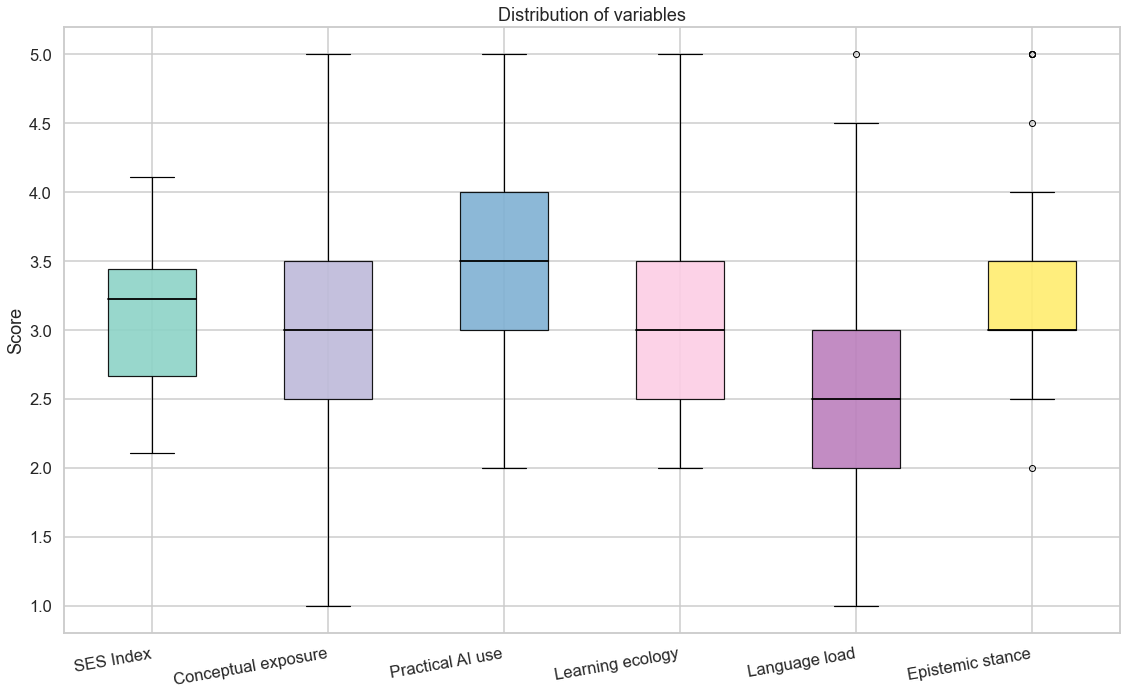

In [28]:
cols = [
    "ses_index",
    "conceptual_exposure_score",
    "practical_ai_use_score",
    "learning_ecology_score",
    "language_load_score",
    "epistemic_stance_score",
]

label_map = {
    "ses_index": "SES Index",
    "conceptual_exposure_score": "Conceptual exposure",
    "practical_ai_use_score": "Practical AI use",
    "learning_ecology_score": "Learning ecology",
    "language_load_score": "Language load",
    "epistemic_stance_score": "Epistemic stance",
}

plot_boxplots(merged_df, cols, label_map=label_map, figsize=(16, 10))

SES of Phase II (41) respondents is slightly higher than Phase I


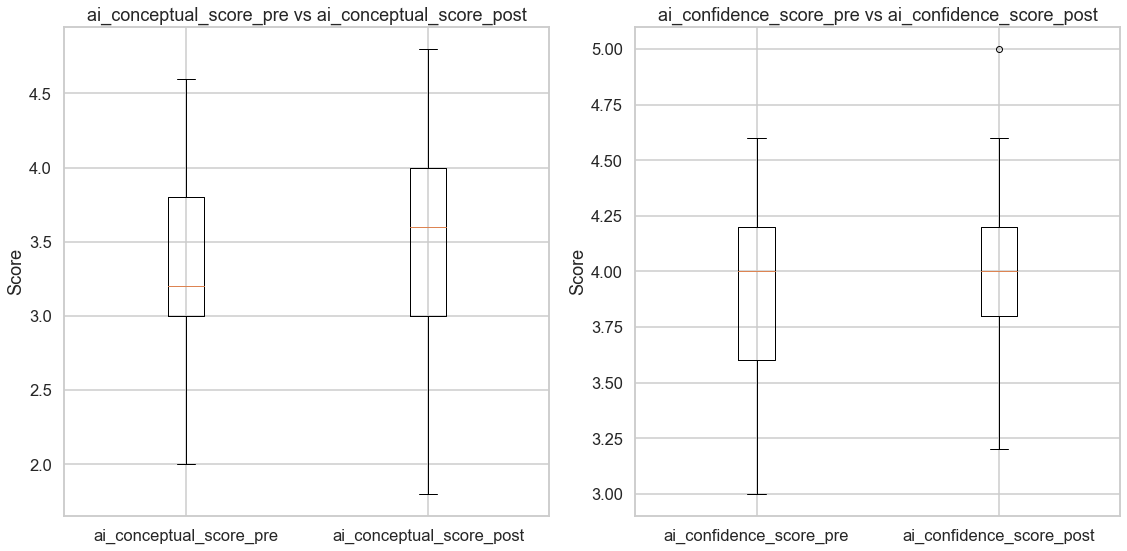

In [29]:
plot_pre_post_boxplots(
    merged_df,
    pairs=[
        ("ai_conceptual_score_pre", "ai_conceptual_score_post"),
        ("ai_confidence_score_pre", "ai_confidence_score_post"),
    ],
    label_map=ai_label_map,
    figsize=(16, 8)
)

# Simple Statistical Tests

If post-intervention data is higher AI literacy than pre-intervention. (One-tailed test)

$$
H_0: \text{AI literacy}_{post} = \text{AI literacy}_{pre}\\
H_a: \text{AI literacy}_{post} > \text{AI literacy}_{pre}
$$

In [30]:
run_ai_pre_post_tests(merged_df)

,mean_change_post_minus_pre,wilcoxon_p,cohens_dz,wilcoxon_p_adj,wilcoxon_sig_adj
Ai_understanding,0.190244,0.022986,0.293587,0.045972,True
Ai_confidence,0.058537,0.218122,0.121928,0.218122,False


**After multiple testing correction, only Ai_Conceptual_Score after intervention is significantly higher.**

--------------

# Rebuild Network analysis

## Two-wave network heatmap

After controlling for SES, mediators, and baseline AI literacy, what still has a unique association with post AI literacy (Pairwise comparisons)?

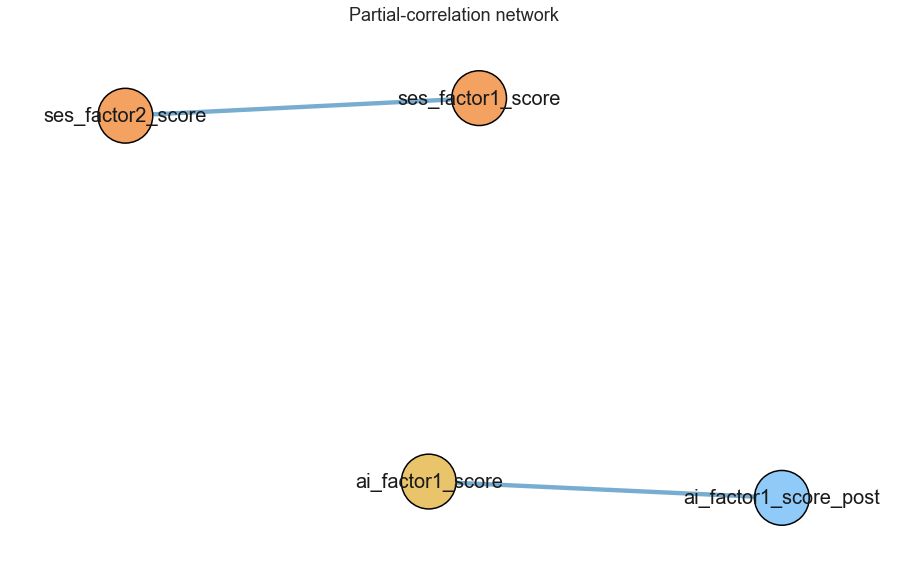

In [31]:
two_wave_res = run_two_wave_ai_network(
    merged_df,
    alpha=0.05,
    adjust_method="fdr_bh",
    min_abs_r=0.0,
    node_groups=node_groups_two_wave
)

plot_network_graph(two_wave_res["graph"], layout="spring", figsize=(16, 10))

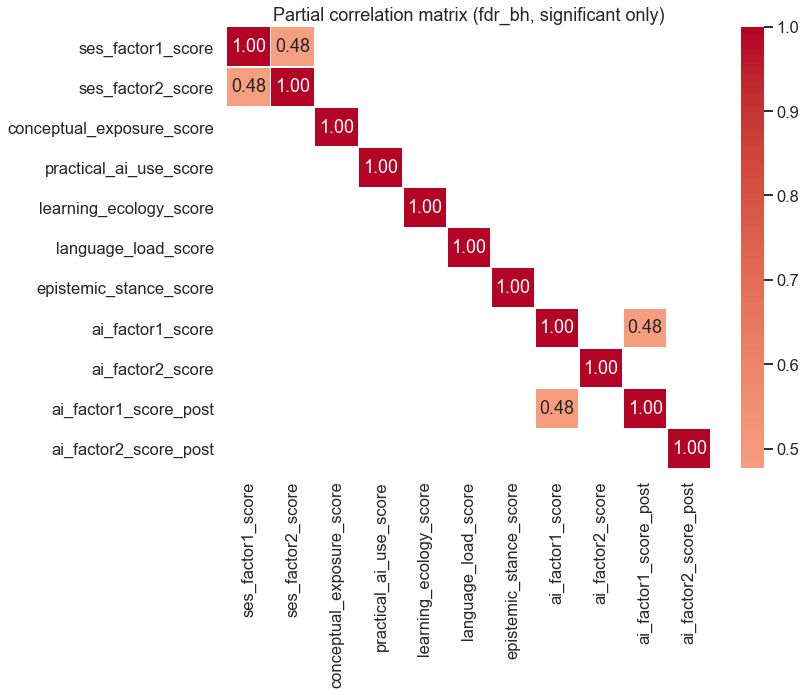

In [32]:
plot_partial_corr_heatmap(
    two_wave_res["pc_obj"],
    adjust_method="fdr_bh",
    alpha=0.05,
    sig_only=True,
    figsize=(12, 10)
)

- **Results**

    1.  Pre-intervention AI understanding is still uniquely related to post AI understanding

    2.  All mediators are NOT uniquely related to post AI

    3.  Mediator–AI links that were visible at phase I no longer survive in Phase II.

## Delta-AI literacy scores (post - pre)

$$
\Delta AI\_factor1 = AI\_factor1^{post} - AI\_factor1^{pre}\\
\Delta AI\_factor2 = AI\_factor2^{post} - AI\_factor2^{pre}
$$

After controlling for all the other variables in this set, which variables still have a unique association with AI literacy improvement (Understanding and Confidence)?

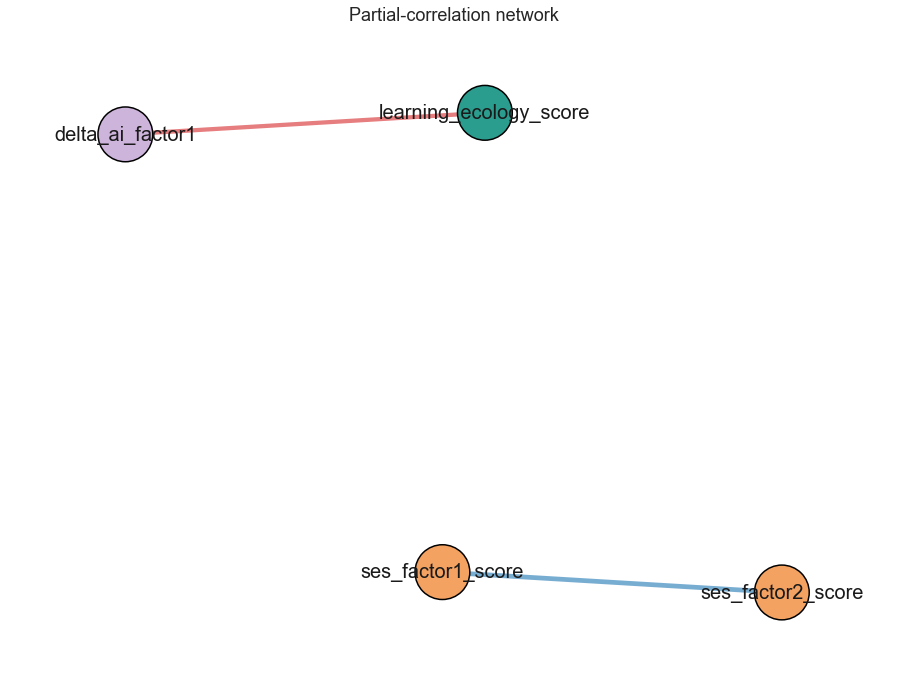

In [33]:
change_res = run_change_score_ai_network(
    merged_df,
    alpha=0.05,
    adjust_method="fdr_bh",
    min_abs_r=0.0,
    node_groups=node_groups_change
)

plot_network_graph(change_res["graph"], layout="spring", figsize=(16, 12))

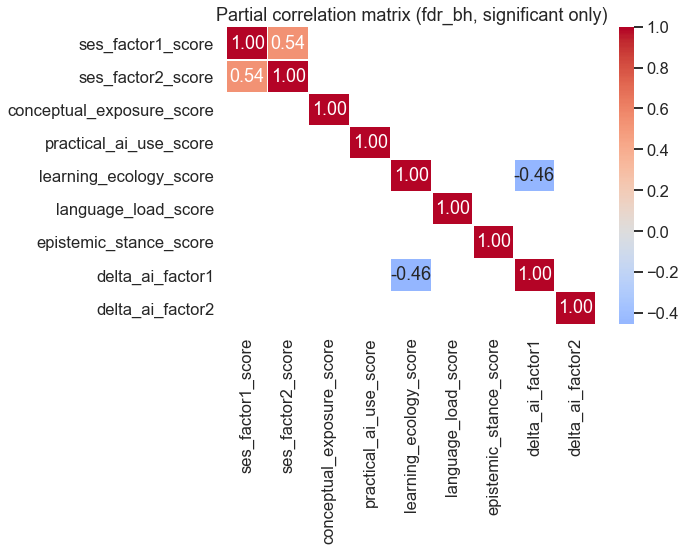

In [34]:
plot_partial_corr_heatmap(
    change_res["pc_obj"],
    adjust_method="fdr_bh",
    alpha=0.05,
    sig_only=True,
    figsize=(10, 8)
)

- **Results**

    1.  learning_ecology_score ↔ delta_ai_factor1 (AI Understanding Improvement) = -0.46
        
        Students with lower baseline learning ecology tended to show larger gains in AI understanding
    
    2. No variables are uniquely associated with delta_ai_factor2 (AI Confidence Improvement)
    
        No strong conditional association between AI_confidence improvement and the SES/mediator variables survived in Phase II

----------

# AI Literacy Gain in different SES groups

t-tests: Does AI literacy gain differ across SES groups?

$$
H_0:\ \mu_{\text{Low SES}}=\mu_{\text{High SES}}
$$

$$
\mu = E(AI\ Literacy\ Post - AI\ Literacy\ Pre)
$$

The splitting of three SES groups is based on the quantiles of the composite SES score. So sample size is roughly equal across groups.

In [35]:
ses_gain_results = compare_gain_by_all_ses_binary(

    df=merged_df,
    ses_cols=["ses_index"],
    pre_post_pairs={
        "delta_ai_factor1": ("ai_conceptual_score_pre", "ai_conceptual_score_post"),
        "delta_ai_factor2": ("ai_confidence_score_pre", "ai_confidence_score_post"),
    },
    alpha=0.05
)
ses_gain_results["results"].round(3)

,ses_col,gain,test,mean_diff,p_value,p_value_adj,sig_adj
0,ses_index,delta_ai_factor1,Welch t-test,-0.156,0.419,0.839,False
1,ses_index,delta_ai_factor2,Welch t-test,0.104,0.475,0.839,False


- **Results**:

     1.  There is no statistically significant difference in AI understanding or confidence gain between the low and high SES groups.
     
     2. There is no evidence that any specific SES groups benefited differently

---------

# Compare gains by two key mediators

t-tests: Does AI literacy gain differ between low and high mediator groups?

* learning_ecology_score
* language_load_score

$$
H_0:\ \mu_{\text{Low Mediator}}=\mu_{\text{High Mediator}}
$$


In [36]:
medi_gain_results = compare_gain_by_key_mediator_binary(
    df=merged_df,
    mediator_cols=("learning_ecology_score", "language_load_score"),
    pre_post_pairs={
        "delta_ai_factor1": ("ai_conceptual_score_pre", "ai_conceptual_score_post"),
        "delta_ai_factor2": ("ai_confidence_score_pre", "ai_confidence_score_post"),
    },
    alpha=0.05
)
medi_gain_results["results"].round(3)

,mediator,gain,test,mean_diff,p_value,p_value_adj,sig_adj
0,learning_ecology_score,delta_ai_factor1,Welch t-test,0.209,0.313,1.0,False
1,learning_ecology_score,delta_ai_factor2,Welch t-test,0.055,0.745,1.0,False
2,language_load_score,delta_ai_factor1,Welch t-test,-0.180,0.386,1.0,False
3,language_load_score,delta_ai_factor2,Welch t-test,-0.007,0.967,1.0,False


- **Results**:

    1.  There is no statistically significant difference in AI understanding or confidence gain across the two levels of learning ecology and language load.

     2. There is no evidence that any specific level of learning ecology or language load benefited differently

-----------

# Does mediator still predict AI Understanding in phase II.

In Phase I, we found that learning ecology and language load were the two strongest mediators that uniquely predict AI understanding after controlling for SES. Do they still predict AI understanding in Phase II after controlling for the same set of variables?


$$
AI1_{\text{post},i} = \beta_0 + \beta_1 AI1_{\text{pre},i} + \beta_2 M_i + \varepsilon_i
$$


M = learning_ecology_score or language_load_score

In [37]:
phase2_mediator_results = test_phase1_ai_understanding_mediators_in_phase2(
    df=merged_df,
    mediators=("language_load_score", "epistemic_stance_score"),
    pre_col="ai_conceptual_score_pre",
    post_col="ai_conceptual_score_post",
    alpha=0.05,
    p_adjust_method="holm"
)

phase2_mediator_results["coef_table"].round(3)

,mediator,term,beta,p_value,ci_low_95,ci_high_95,p_value_adj,sig_adj
0,language_load_score,ai_conceptual_score_pre,0.608,0.000,0.364,0.852,NaN,False
1,language_load_score,language_load_score,0.046,0.716,-0.199,0.290,0.716,False
2,epistemic_stance_score,ai_conceptual_score_pre,0.465,0.001,0.197,0.733,NaN,False
3,epistemic_stance_score,epistemic_stance_score,0.338,0.001,0.137,0.539,0.002,True


WE only adjust for p-value for mediator terms.

- **Results**:

    1. Once baseline AI understanding is controlled, language load no longer predicts post AI understanding

    2. Even after controlling for baseline AI understanding, epistemic stance still predicts post AI understanding

- **The intervention may have reduced the extent to which students’ final AI understanding depends on their baseline language burden.**

- Students with a stronger epistemic stance still tend to end up with better post-intervention AI understanding, even after accounting for where they started.